In [51]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error


RUN_EDA = False 

In [52]:
real_estate = pd.read_csv("india_housing_prices.csv")

In [53]:
# Data cleaning
real_estate = real_estate.drop_duplicates()
real_estate.fillna(method='ffill', inplace=True)

print("✅ Data cleaned")

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_20268\1333292144.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  real_estate.fillna(method='ffill', inplace=True)


✅ Data cleaned


In [54]:
# FEATURE ENGINEERING

# Price per sqft
real_estate["Price_per_SqFt"] = (
    real_estate["Price_in_Lakhs"] * 100000 /
    real_estate["Size_in_SqFt"].replace(0, np.nan)
)

# Numeric conversion
cols = ["Nearby_Schools", "Nearby_Hospitals", "Public_Transport_Accessibility"]
for col in cols:
    real_estate[col] = pd.to_numeric(real_estate[col], errors='coerce')

real_estate[cols] = real_estate[cols].fillna(0)

# Amenity Score
real_estate["Amenity_Score"] = (
    real_estate["Nearby_Schools"] +
    real_estate["Nearby_Hospitals"] +
    real_estate["Public_Transport_Accessibility"]
)

# Age of property
real_estate["Age_of_Property"] = 2025 - real_estate["Year_Built"]

# Good Investment
price_median = real_estate["Price_per_SqFt"].median()
amenity_median = real_estate["Amenity_Score"].median()

real_estate["Good_Investment"] = np.where(
    (real_estate["Price_per_SqFt"] < price_median) &
    (real_estate["Amenity_Score"] > amenity_median) &
    (real_estate["Age_of_Property"] < 10),
    1, 0
)

# Future price
growth_rate = 0.08
years = 5

real_estate["Future_Price_5Y"] = (
    real_estate["Price_in_Lakhs"] * (1 + growth_rate) ** years
)

print("✅ Feature Engineering done")

✅ Feature Engineering done


EDA (Exploratory Data Analysis)


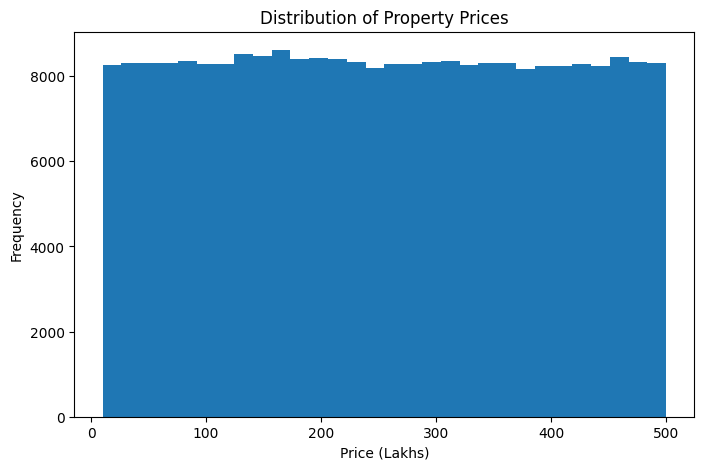

In [55]:

#1.What is the distribution of property prices?

plt.figure(figsize=(8,5))
plt.hist(real_estate["Price_in_Lakhs"], bins=30)
plt.title("Distribution of Property Prices")
plt.xlabel("Price (Lakhs)")
plt.ylabel("Frequency")
plt.show()

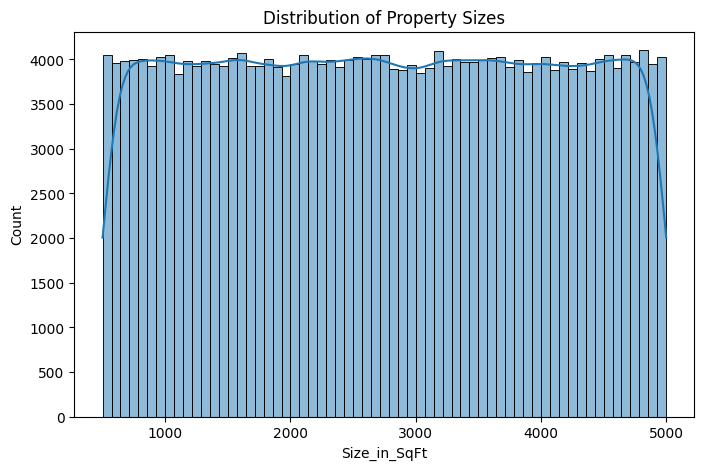

In [56]:
#2.What is the distribution of property sizes?

plt.figure(figsize=(8,5))
sns.histplot(real_estate["Size_in_SqFt"], kde=True)
plt.title("Distribution of Property Sizes")
plt.show()

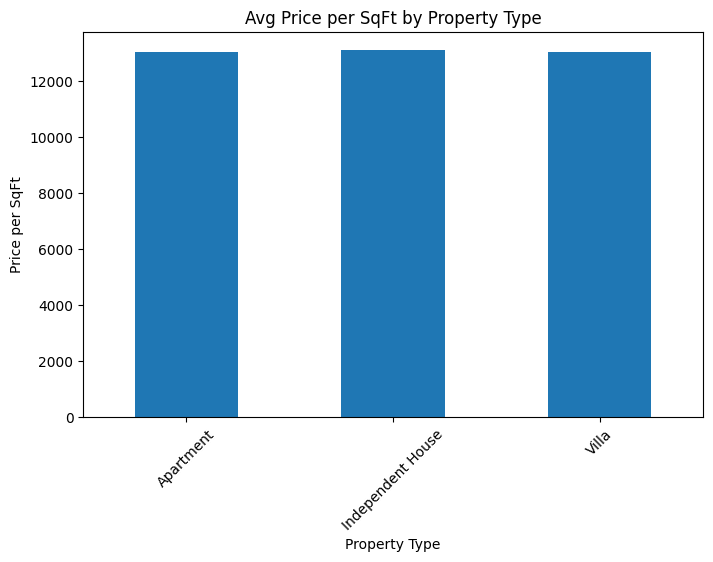

In [57]:
#3.How does the price per sq ft vary by property type?

avg_price = real_estate.groupby("Property_Type")["Price_per_SqFt"].mean()

avg_price.plot(kind='bar', figsize=(8,5))

plt.title("Avg Price per SqFt by Property Type")
plt.xlabel("Property Type")
plt.ylabel("Price per SqFt")
plt.xticks(rotation=45)
plt.show()

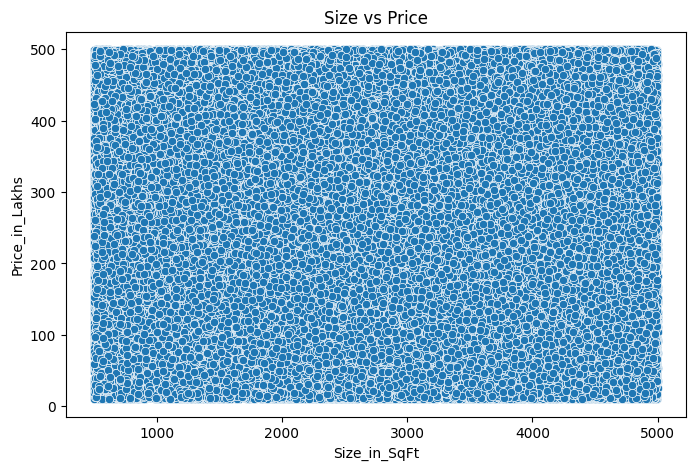

In [58]:
#4.Is there a relationship between property size and price?


plt.figure(figsize=(8,5))
sns.scatterplot(x="Size_in_SqFt", y="Price_in_Lakhs", data=real_estate)
plt.title("Size vs Price")
plt.show()

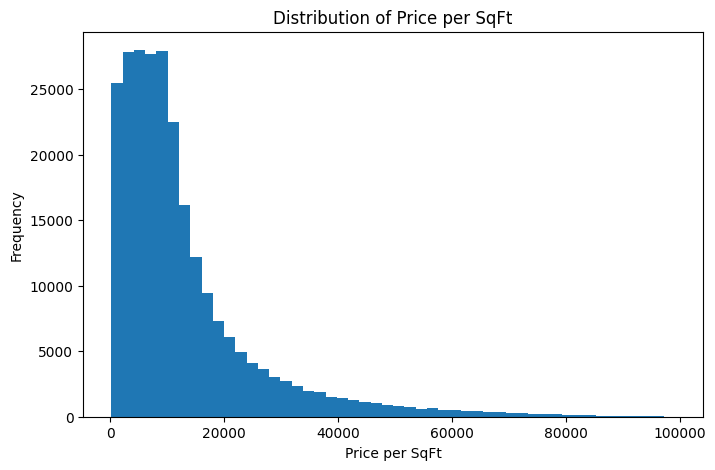

In [59]:
#5. Are there any outliers in price per sq ft or property size?

plt.figure(figsize=(8,5))

plt.hist(real_estate["Price_per_SqFt"], bins=50)

plt.title("Distribution of Price per SqFt")
plt.xlabel("Price per SqFt")
plt.ylabel("Frequency")

plt.show()

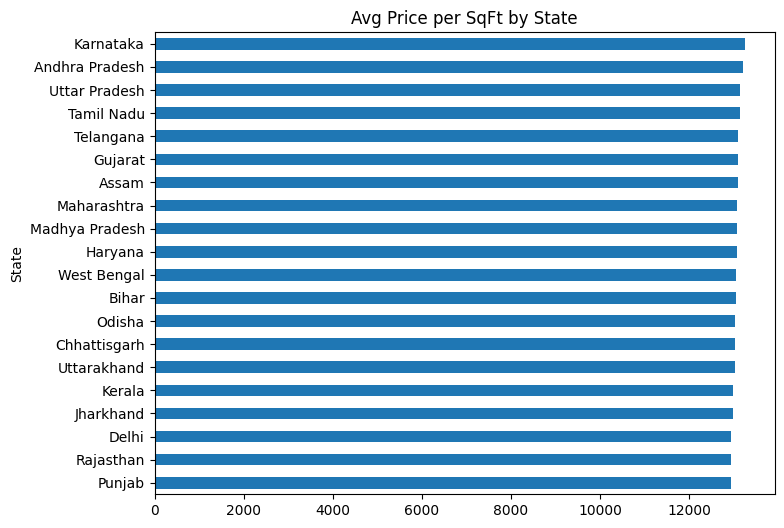

In [60]:
#6.What is the average price per sq ft by state?


state_price = real_estate.groupby("State")["Price_per_SqFt"].mean().sort_values()

state_price.plot(kind='barh', figsize=(8,6))
plt.title("Avg Price per SqFt by State")
plt.show()

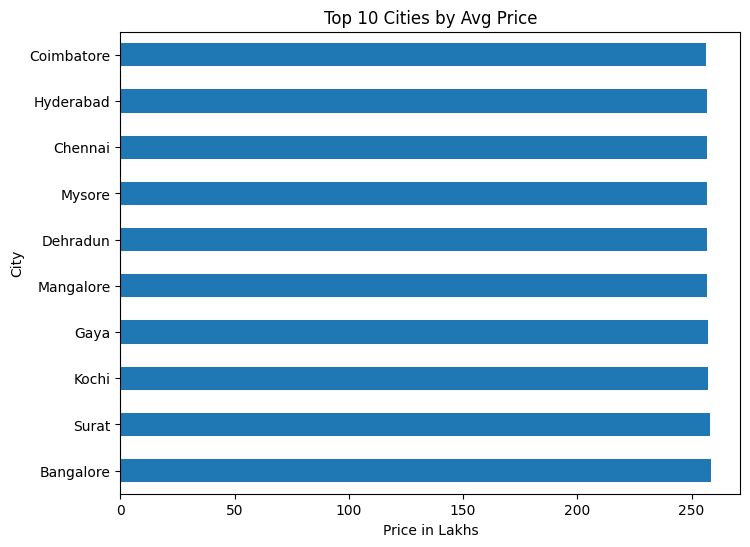

In [61]:
#7. What is the average property price by city?

city_price = real_estate.groupby("City")["Price_in_Lakhs"].mean().sort_values(ascending=False).head(10)

city_price.plot(kind='barh', figsize=(8,6))
plt.title("Top 10 Cities by Avg Price")
plt.xlabel("Price in Lakhs")
plt.show()

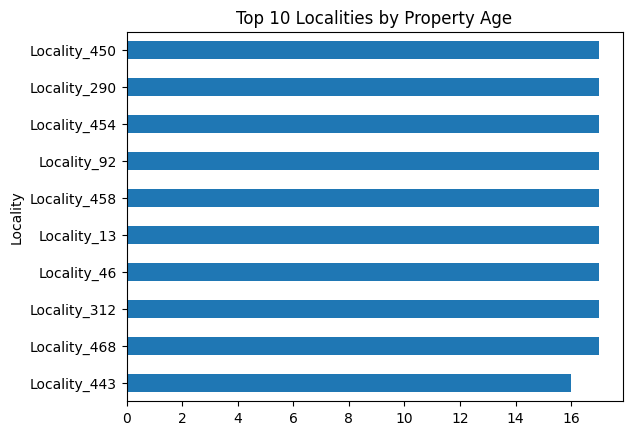

In [62]:
#8.What is the median age of properties by locality?

locality_age = real_estate.groupby("Locality")["Age_of_Property"].median().sort_values()

locality_age.head(10).plot(kind='barh')
plt.title("Top 10 Localities by Property Age")
plt.show()

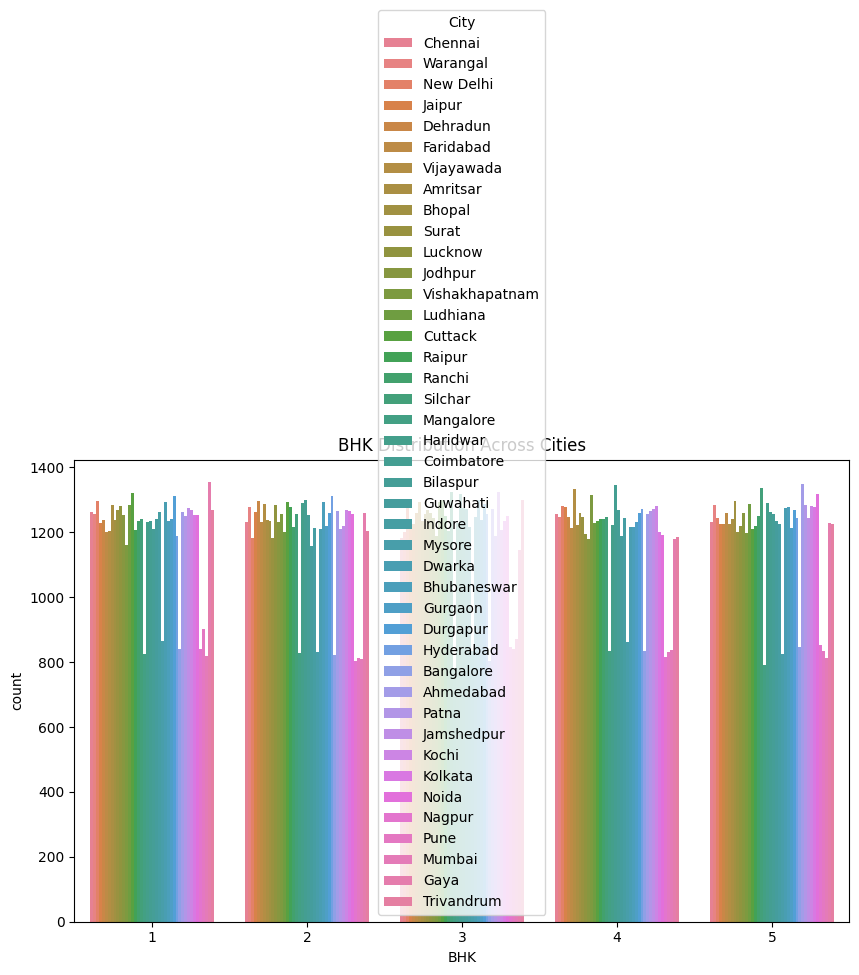

In [63]:
#9.How is BHK distributed across cities?

plt.figure(figsize=(10,6))
sns.countplot(x="BHK", hue="City", data=real_estate)
plt.title("BHK Distribution Across Cities")
plt.show()

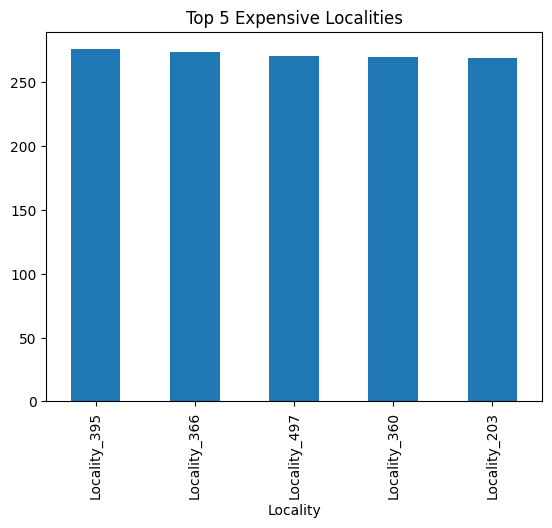

In [64]:
#10.What are the price trends for the top 5 most expensive localities?

top_localities = real_estate.groupby("Locality")["Price_in_Lakhs"].mean().nlargest(5)

top_localities.plot(kind='bar')
plt.title("Top 5 Expensive Localities")
plt.show()

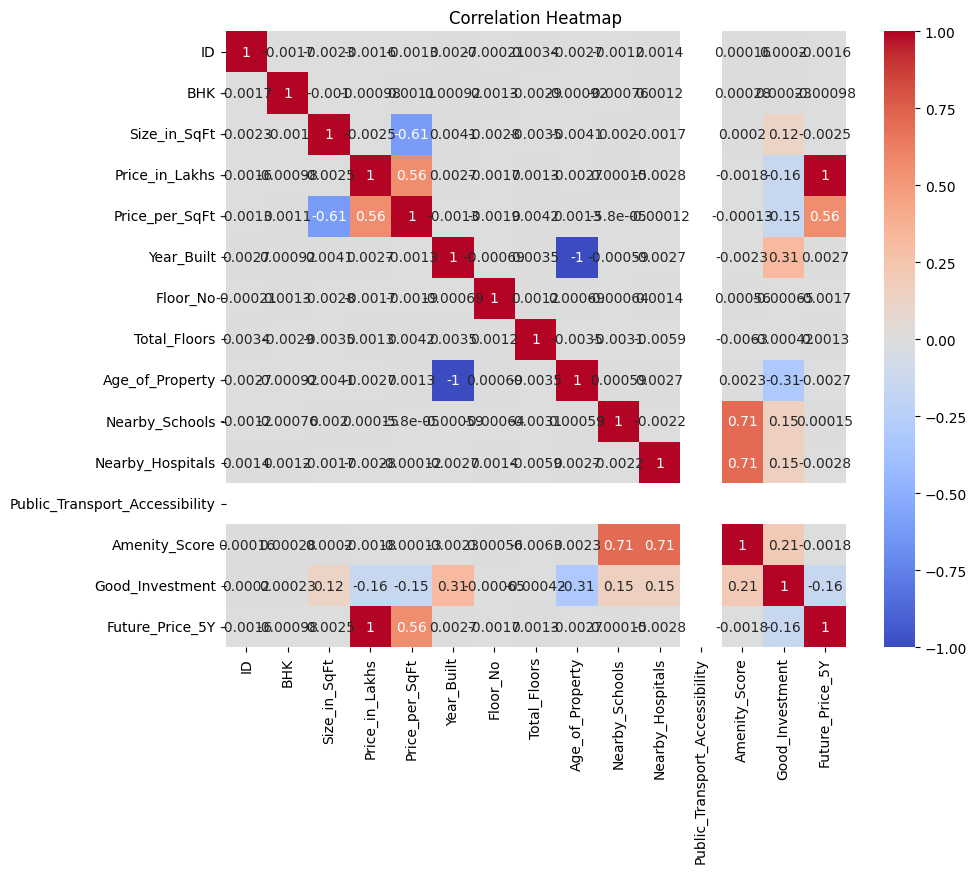

In [65]:
#11. How are numeric features correlated with each other?

plt.figure(figsize=(10,8))
sns.heatmap(real_estate.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

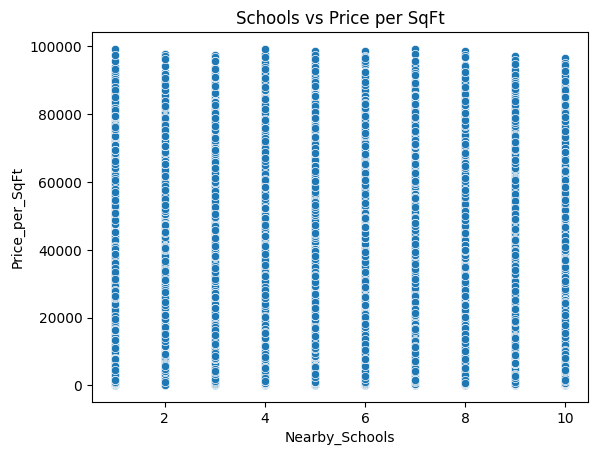

In [66]:
#12.How do nearby schools relate to price per sq ft?

sns.scatterplot(x="Nearby_Schools", y="Price_per_SqFt", data=real_estate)
plt.title("Schools vs Price per SqFt")
plt.show()

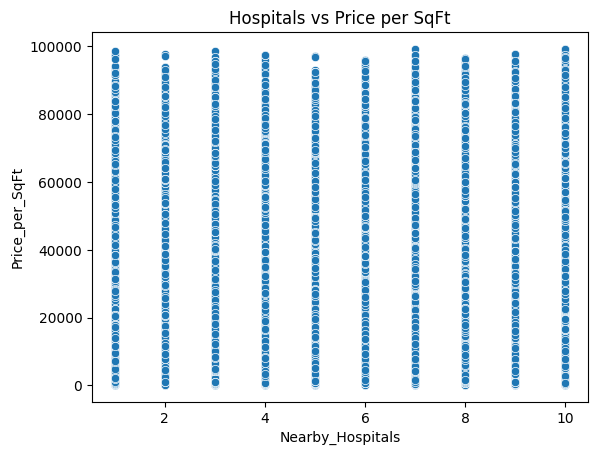

In [67]:
#13. How do nearby hospitals relate to price per sq ft?

sns.scatterplot(x="Nearby_Hospitals", y="Price_per_SqFt", data=real_estate)
plt.title("Hospitals vs Price per SqFt")
plt.show()

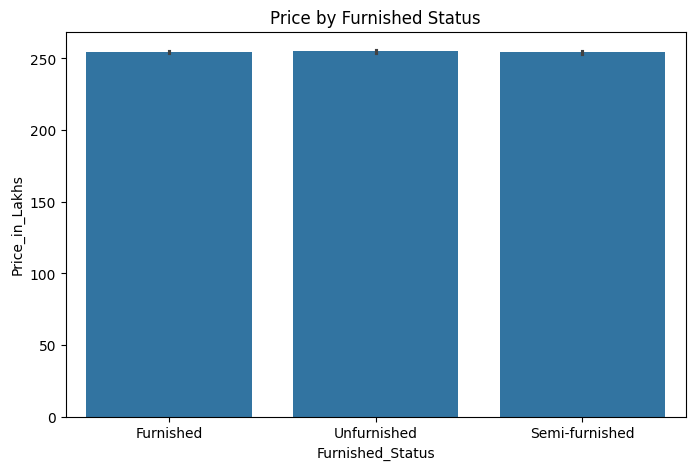

In [68]:
#14. How does price vary by furnished status?

plt.figure(figsize=(8,5))
sns.barplot(x="Furnished_Status", y="Price_in_Lakhs", data=real_estate)
plt.title("Price by Furnished Status")
plt.show()

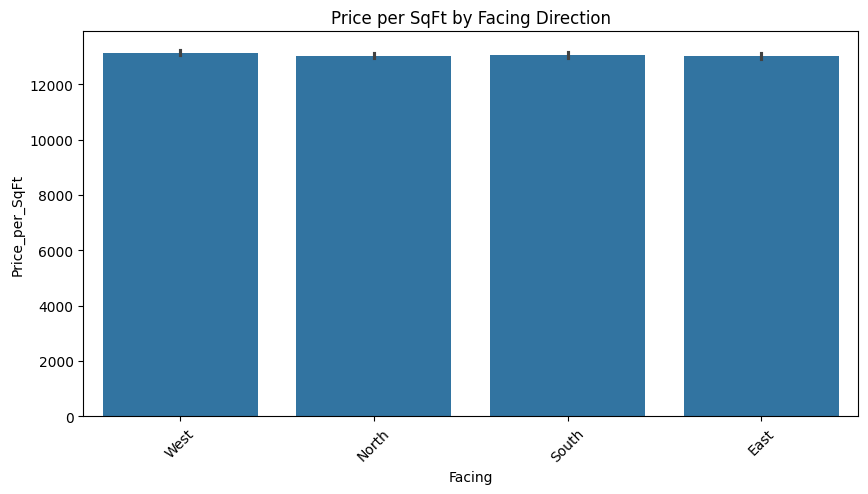

In [69]:
#15. How does price per sq ft vary by property facing direction?

plt.figure(figsize=(10,5))
sns.barplot(x="Facing", y="Price_per_SqFt", data=real_estate)
plt.title("Price per SqFt by Facing Direction")
plt.xticks(rotation=45)
plt.show()

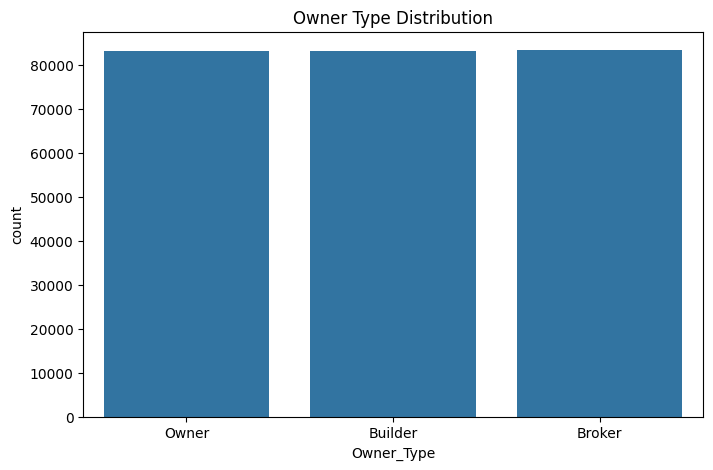

In [70]:
#16. How many properties belong to each owner type?

plt.figure(figsize=(8,5))
sns.countplot(x="Owner_Type", data=real_estate)
plt.title("Owner Type Distribution")
plt.show()

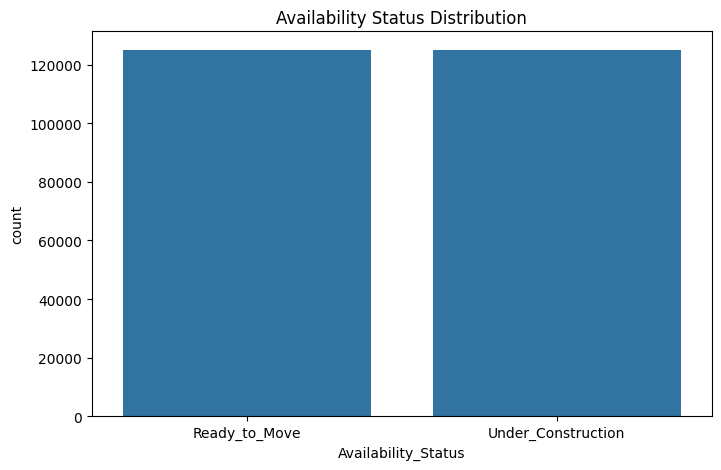

In [71]:
#17.How many properties are available under each availability status?

plt.figure(figsize=(8,5))
sns.countplot(x="Availability_Status", data=real_estate)
plt.title("Availability Status Distribution")
plt.show()

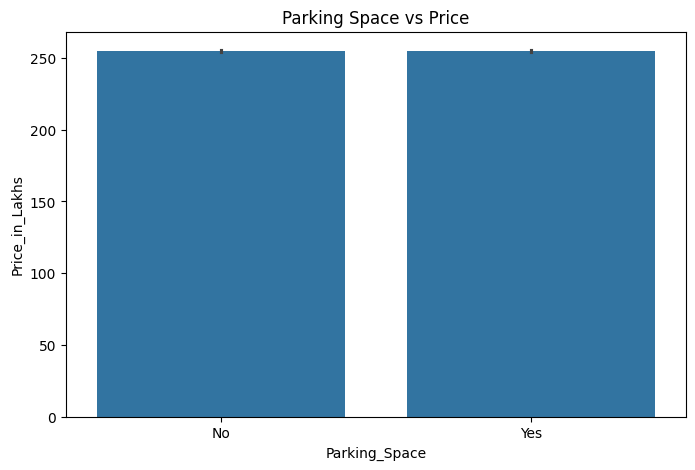

In [72]:
#18.Does parking space affect property price?

plt.figure(figsize=(8,5))
sns.barplot(x="Parking_Space", y="Price_in_Lakhs", data=real_estate)
plt.title("Parking Space vs Price")
plt.show()

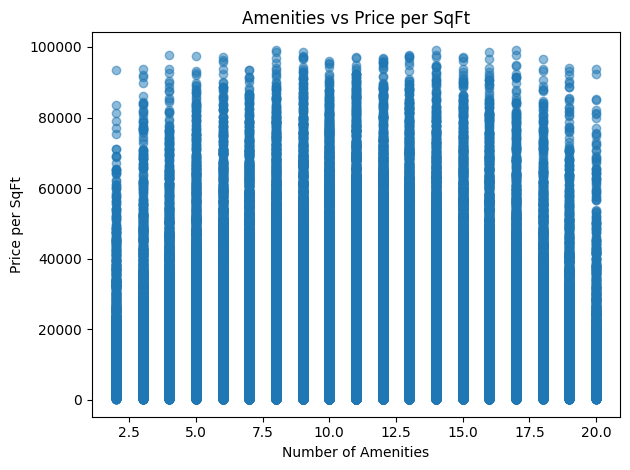

In [73]:
#19.How do amenities affect price per sq ft?

plt.figure()
plt.scatter(real_estate["Amenity_Score"], real_estate["Price_per_SqFt"], alpha=0.5)

plt.title("Amenities vs Price per SqFt")
plt.xlabel("Number of Amenities")
plt.ylabel("Price per SqFt")

plt.tight_layout()
plt.show()

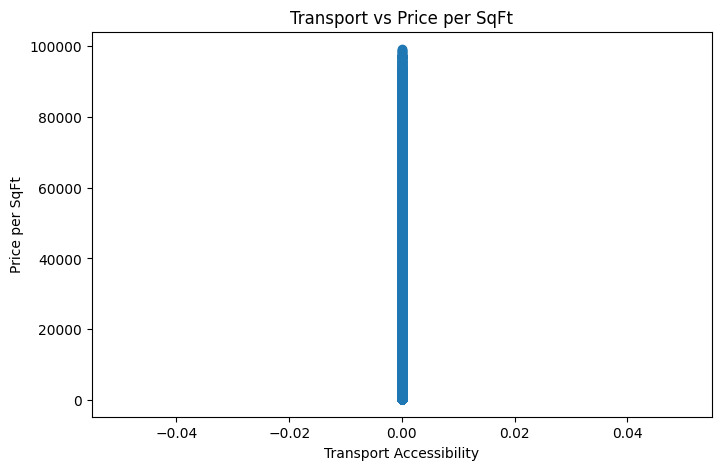

In [74]:
#20.How does public transport accessibility relate to price per sq ft or investment potential?

plt.figure(figsize=(8,5))
plt.scatter(real_estate["Public_Transport_Accessibility"], real_estate["Price_per_SqFt"])
plt.xlabel("Transport Accessibility")
plt.ylabel("Price per SqFt")
plt.title("Transport vs Price per SqFt")
plt.show()

In [75]:
cat_cols = real_estate.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['State', 'City', 'Locality', 'Property_Type', 'Furnished_Status',
       'Parking_Space', 'Security', 'Amenities', 'Facing', 'Owner_Type',
       'Availability_Status'],
      dtype='object')


In [ ]:
# ENCODING 

cat_cols = [
    "State","Property_Type","City","Locality","Parking_Space","Security","Amenities",
    "Furnished_Status","Facing",
    "Owner_Type","Availability_Status"
]

df = pd.get_dummies(real_estate, columns=cat_cols, drop_first=True)




In [77]:
# TRAIN TEST SPLIT

X = df.drop(["Future_Price_5Y", "Good_Investment", "ID"], axis=1)
y = df["Future_Price_5Y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [78]:
# SCALING

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [79]:
# MLFLOW SETUP (FIXED)

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("RealEstateProject")


2026/04/04 18:48:53 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/04/04 18:48:53 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/04/04 18:48:53 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/04/04 18:48:53 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/04/04 18:48:54 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/04/04 18:48:54 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/04/04 18:48:56 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/04/04 18:48:57 INFO alembic.runtime.migration: Will assume non-transactional DDL.


<Experiment: artifact_location='file:///c:/Users/ADMIN/Desktop/AI-ML/Projects/Real Estate/mlruns/1', creation_time=1775302397651, experiment_id='1', last_update_time=1775302397651, lifecycle_stage='active', name='RealEstateProject', tags={}>

In [80]:
# MODEL TRAINING (FAST)

with mlflow.start_run():

    model = RandomForestRegressor(
        n_estimators=30,   # reduced → faster
        max_depth=10,      # controlled complexity
        n_jobs=-1,
        random_state=42
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Log to MLflow
    mlflow.log_param("model", "RandomForest")
    mlflow.log_param("n_estimators", 30)
    mlflow.log_metric("rmse", rmse)

    mlflow.sklearn.log_model(model, "model")

print("✅ Model trained & logged")

2026/04/04 18:54:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
c:\Users\ADMIN\anaconda\anaconda\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)


✅ Model trained & logged


In [82]:
# SAVE MODEL

pickle.dump(model, open("reg_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

train_columns = X.columns
pickle.dump(train_columns, open("columns.pkl", "wb"))

print("✅ Model saved successfully")

✅ Model saved successfully
